# Uber Bike Share — SF Trips Analysis
**Author:** Rudraja Vansutre  
**Dataset:** Uber Bay Area Bike Share — San Francisco trips only  
**Notebook 2 of 2** — EDA, temporal patterns, user behaviour, route analysis, bike utilisation, and station flow.

In [2]:
import os
os.listdir(r"C:\Users\RUDRAJA\Desktop\UBER DATA")


['.ipynb_checkpoints',
 'bike_data.csv',
 'Book1.twb',
 'Copy of Analytics Exercise Data.xlsx',
 'Dashboard- UBER.twb',
 'Dashboard.twb',
 'DOC.docx',
 'SF_Trips.csv',
 'SF_Trips.ipynb',
 'SS',
 'top_routes.csv',
 'UBER bike_rides.ipynb',
 'UBER presentation.docx',
 'UBER_SF_BikeShare.pptx',
 '~$UBER_SF_BikeShare.pptx',
 '~Book1__26560.twbr',
 '~Dashboard- UBER__16492.twbr']

## 1. Setup & Load Data

We load the cleaned SF_trips CSV 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

sf_df = pd.read_csv(r"C:\Users\RUDRAJA\Desktop\UBER DATA\SF_Trips.csv")
print(sf_df.shape)      # to check rows and columns
print(sf_df.columns)    # to see column names
sf_df.head()


(70897, 14)
Index(['Trip ID', 'Duration', 'Start Date', 'Start Station', 'Start Terminal',
       'End Date', 'End Station', 'End Terminal', 'Bike #', 'Subscriber Type',
       'Zip Code', 'Station_Type', 'Zip Code Clean', 'Trip Duration Min'],
      dtype='object')


,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscriber Type,Zip Code,Station_Type,Zip Code Clean,Trip Duration Min
0,431032,1648,2014-08-29 15:33:00,Steuart at Market,74,2014-08-29 16:00:00,San Francisco Caltrain (Townsend at 4th),70,411,Subscriber,94107,SF Station,94107,27.47
1,383548,617,2014-07-28 17:35:00,Steuart at Market,74,2014-07-28 17:45:00,San Francisco Caltrain (Townsend at 4th),70,259,Subscriber,94403,SF Station,94403,10.28
2,257887,551,2014-04-22 19:19:00,Post at Kearny,47,2014-04-22 19:28:00,South Van Ness at Market,66,414,Subscriber,94105,SF Station,94105,9.18
3,334581,327,2014-06-22 19:36:00,5th at Howard,57,2014-06-22 19:42:00,2nd at Folsom,62,553,Subscriber,94103,SF Station,94103,5.45
4,268757,382,2014-05-01 19:37:00,Clay at Battery,41,2014-05-01 19:44:00,Market at 4th,76,501,Subscriber,94612,SF Station,94612,6.37


### **Known Vs Unknown Graph**

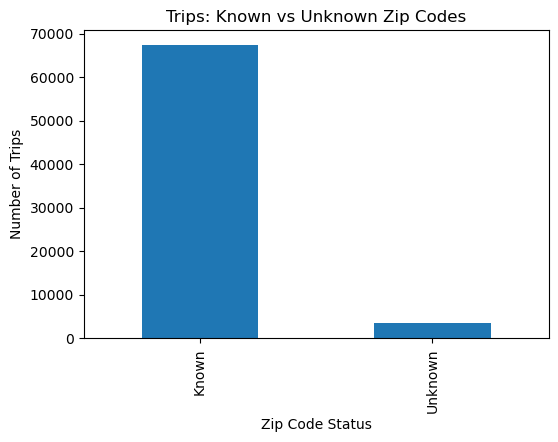

In [6]:


# Create a flag for known vs unknown zip codes
sf_df['Zip Code Clean'] = sf_df['Zip Code Clean'].astype(str).str.strip()
sf_df['zip_known'] = sf_df['Zip Code Clean'].apply(lambda z: str(z).isdigit() and len(str(z)) == 5)

# Count known vs unknown
zip_counts = sf_df['zip_known'].value_counts().rename(index={True: "Known", False: "Unknown"})

# --- Plot 1: Bar chart ---
plt.figure(figsize=(6,4))
zip_counts.plot(kind='bar')
plt.title("Trips: Known vs Unknown Zip Codes")
plt.ylabel("Number of Trips")
plt.xlabel("Zip Code Status")
plt.show()



In [7]:
# Count known vs unknown
zip_counts = sf_df['zip_known'].value_counts().rename(index={True: "Known", False: "Unknown"})
print(zip_counts)

# Also show percentages
zip_percent = (zip_counts / zip_counts.sum() * 100).round(2)
print("\nPercentages:\n", zip_percent)


zip_known
Known      67454
Unknown     3443
Name: count, dtype: int64

Percentages:
 zip_known
Known      95.14
Unknown     4.86
Name: count, dtype: float64


### **HeatMap of Trips**

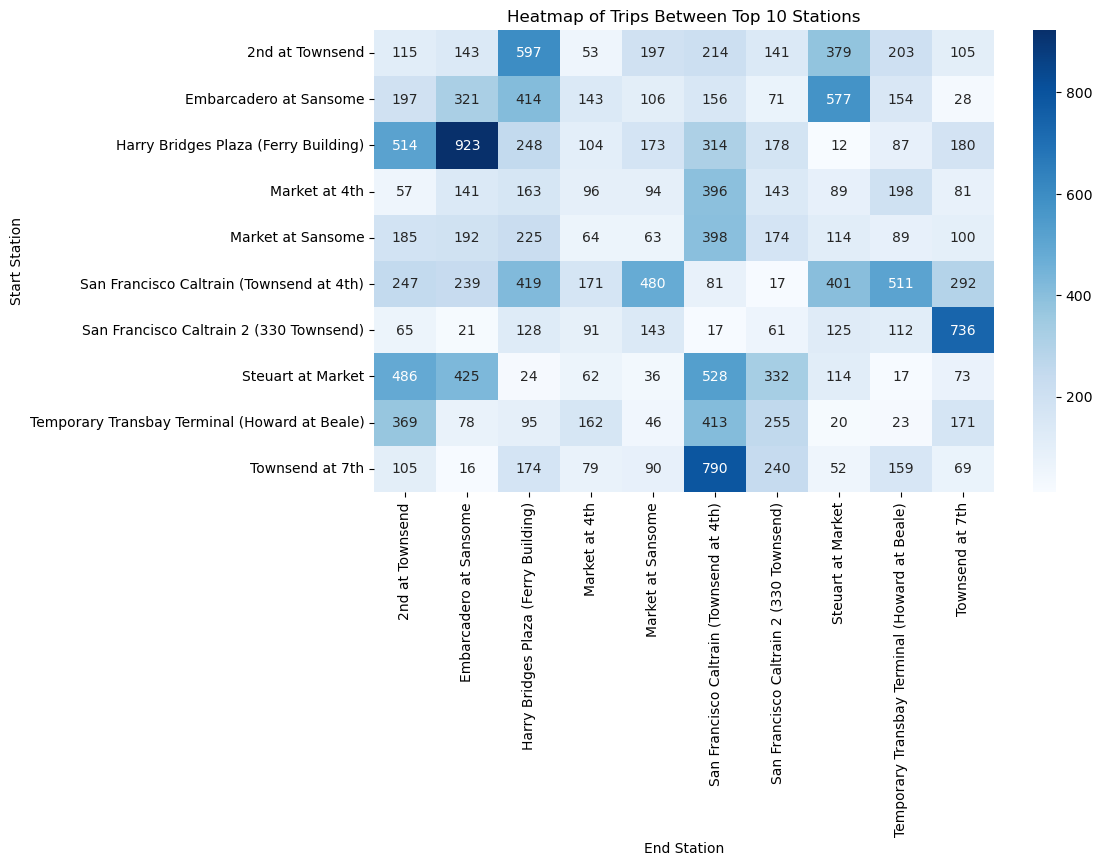

In [9]:
import seaborn as sns

# Top 10 start stations
top_stations = sf_df['Start Station'].value_counts().head(10).index

# Filter data
filtered = sf_df[sf_df['Start Station'].isin(top_stations) & sf_df['End Station'].isin(top_stations)]
route_matrix = filtered.groupby(['Start Station','End Station']).size().unstack(fill_value=0)

# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(route_matrix, cmap="Blues", annot=True, fmt="d", cbar=True)
plt.title("Heatmap of Trips Between Top 10 Stations")
plt.xlabel("End Station")
plt.ylabel("Start Station")
plt.show()


In [10]:
sf_df['Trip Duration Min'].max()


4136.92

## Bike Utilization Analysis

This section analyzes total ride time per bike to understand utilization patterns across the fleet.

Trip durations are aggregated at the bike level and grouped into predefined buckets (0–500, 500–1500, 1500–3000, 3000+ minutes). This helps identify how evenly bikes are being used and whether a subset of bikes is over- or under-utilized.

The distribution of bikes across these buckets provides insight into operational efficiency and potential maintenance or rebalancing needs.

In [12]:

# clean & aggregate total minutes per bike
bike_minutes = (
    sf_df
    .assign(**{'Trip Duration Min': pd.to_numeric(sf_df['Trip Duration Min'], errors='coerce')})
    .dropna(subset=['Trip Duration Min'])
    .groupby('Bike #', as_index=False)['Trip Duration Min']
    .sum()
    .rename(columns={'Trip Duration Min': 'total_minutes'})
)

# define mutually-exclusive buckets (0-500, 500-1500, 1500-3000) + optional 3000+
bins = [0, 500, 1500, 3000, float('inf')]
labels = ['0-500', '500-1500', '1500-3000', '3000+']

bike_minutes['bucket'] = pd.cut(bike_minutes['total_minutes'],
                                bins=bins,
                                labels=labels,
                                right=True,
                                include_lowest=True)

# counts and percentages
total_bikes = len(bike_minutes)
counts = bike_minutes['bucket'].value_counts().reindex(labels, fill_value=0)
pct = (counts / total_bikes * 100).round(2)

# print results
print(f"Total Bikes: {total_bikes}\n")
for lab in labels:
    print(f"{lab}: {counts[lab]} bikes → {pct[lab]}%")
print(f"\nPercentages sum to: {pct.sum()}%")


Total Bikes: 410

0-500: 34 bikes → 8.29%
500-1500: 27 bikes → 6.59%
1500-3000: 130 bikes → 31.71%
3000+: 219 bikes → 53.41%

Percentages sum to: 100.0%


## System Overview and Key Metrics

To understand the overall scale and impact of the bike-sharing system, key performance indicators were calculated.

These metrics capture:
- Total demand through ride volume  
- Fleet utilization via number of bikes  
- Geographic reach through zip codes and stations  
- Overall usage intensity through total ride time  

This provides a concise snapshot of system performance before diving into deeper analysis.

In [14]:


# Ensure datetime & duration column
sf_df['Start Date'] = pd.to_datetime(sf_df['Start Date'], errors='coerce')
sf_df['End Date'] = pd.to_datetime(sf_df['End Date'], errors='coerce')

if 'Trip Duration Min' not in sf_df.columns:
    sf_df['Trip Duration Min'] = (sf_df['End Date'] - sf_df['Start Date']).dt.total_seconds() / 60

# --- KPI calculations ---
total_trips = len(sf_df)
unique_bikes = sf_df['Bike #'].nunique()

# Unique zip codes served (drop NaN to avoid counting them)
unique_zipcodes = sf_df['Zip Code'].dropna().nunique()

# Unique stations combining start & end
unique_stations = pd.concat([sf_df['Start Station'], sf_df['End Station']]).nunique()

# Total time spent riding (hours)
total_hours = sf_df['Trip Duration Min'].sum() / 60

# --- Print results ---
print("\n--- KPI Dashboard ---")
print(f"Total Trips: {total_trips:,}")
print(f"Unique Bikes: {unique_bikes:,}")
print(f"Unique Zip Codes Served: {unique_zipcodes:,}")
print(f"Unique Stations (Start + End): {unique_stations:,}")
print(f"Total Ride Time: {total_hours:,.0f} hours (making the earth greener 🌍🚴)")



--- KPI Dashboard ---
Total Trips: 70,897
Unique Bikes: 410
Unique Zip Codes Served: 2,514
Unique Stations (Start + End): 33
Total Ride Time: 20,466 hours (making the earth greener 🌍🚴)


## Trip Duration Patterns and User Behavior

To understand ride behavior, trip durations were analyzed using both mean and median metrics.

Since trip duration data is typically right-skewed, the median provides a more reliable measure of central tendency, while the mean highlights the impact of longer rides.

Segmenting by user type allows us to compare how customers and subscribers differ in their usage patterns, providing insights into commute versus leisure behavior.

In [16]:
# Overall trip duration stats
median_duration = sf_df['Trip Duration Min'].median()
mean_duration = sf_df['Trip Duration Min'].mean()

# Trip duration by user type
median_by_user = sf_df.groupby('Subscriber Type')['Trip Duration Min'].median()
mean_by_user = sf_df.groupby('Subscriber Type')['Trip Duration Min'].mean()

print("\n--- Trip Duration Stats ---")
print(f"Median Trip Duration: {median_duration:.2f} min")
print(f"Mean Trip Duration: {mean_duration:.2f} min (check skew)")

print("\n--- Trip Duration by User Type ---")
for user in median_by_user.index:
    print(f"{user}: Median = {median_by_user[user]:.2f} min, Mean = {mean_by_user[user]:.2f} min")


--- Trip Duration Stats ---
Median Trip Duration: 8.83 min
Mean Trip Duration: 17.32 min (check skew)

--- Trip Duration by User Type ---
Customer: Median = 18.63 min, Mean = 55.91 min
Subscriber: Median = 8.13 min, Mean = 9.76 min


## Demand Patterns Across Time

To understand when users engage with the bike-sharing system, ride activity was analyzed across multiple time dimensions.

- Monthly trends capture seasonality and growth in demand  
- Hourly patterns reveal peak usage periods throughout the day  
- Weekday vs weekend comparison highlights differences between commute-driven and leisure-driven usage  

This analysis provides a comprehensive view of temporal demand patterns.

In [18]:


# Ensure datetime
sf_df['Start Date'] = pd.to_datetime(sf_df['Start Date'], errors='coerce')

# ---------------- Trips per Month ----------------
trips_per_month = sf_df.groupby(sf_df['Start Date'].dt.to_period("M")).size()
monthly_df = trips_per_month.to_frame(name="Trips")
monthly_df['MoM Growth %'] = monthly_df['Trips'].pct_change() * 100
monthly_df['% of Total'] = (monthly_df['Trips'] / monthly_df['Trips'].sum()) * 100

print("\n--- Trips per Month ---")
print(monthly_df)

# Example insights:
# - Which month contributed the most trips
top_month = monthly_df['% of Total'].idxmax()
top_month_share = monthly_df['% of Total'].max()
print(f"\n📌 Peak month: {top_month} → {top_month_share:.2f}% of total trips")

# ---------------- Trips per Hour ----------------
trips_per_hour = sf_df.groupby(sf_df['Start Date'].dt.hour).size().to_frame("Trips")
trips_per_hour['% of Daily Trips'] = (trips_per_hour['Trips'] / trips_per_hour['Trips'].sum()) * 100

print("\n--- Trips per Hour ---")
print(trips_per_hour)

# Peak hours (top 3 by % of trips)
peak_hours = trips_per_hour.sort_values("Trips", ascending=False).head(3)
print("\n📌 Peak hours (top 3):")
for h, row in peak_hours.iterrows():
    print(f"Hour {h}: {row['Trips']} trips ({row['% of Daily Trips']:.2f}%)")

# ---------------- Weekday vs Weekend (optional preview for Slide 3) ----------------
sf_df['Weekday'] = sf_df['Start Date'].dt.weekday
sf_df['Day_Type'] = sf_df['Weekday'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

weekday_split = sf_df['Day_Type'].value_counts(normalize=True) * 100
print("\n--- Weekday vs Weekend Split ---")
print(weekday_split)



--- Trips per Month ---
            Trips  MoM Growth %  % of Total
Start Date                                 
2014-03     10313           NaN   14.546455
2014-04     10819      4.906429   15.260166
2014-05     11500      6.294482   16.220715
2014-06     12448      8.243478   17.557866
2014-07     12969      4.185411   18.292735
2014-08     12848     -0.932994   18.122064

📌 Peak month: 2014-07 → 18.29% of total trips

--- Trips per Hour ---
            Trips  % of Daily Trips
Start Date                         
0             182          0.256710
1              78          0.110019
2              59          0.083219
3              25          0.035262
4              35          0.049367
5             293          0.413276
6            1353          1.908402
7            4568          6.443150
8            9018         12.719861
9            6541          9.226060
10           3101          4.373951
11           3123          4.404982
12           3659          5.161008
13          

In [19]:
# --- Ensure datetime and trip duration ---
sf_df['Start Date'] = pd.to_datetime(sf_df['Start Date'], errors='coerce')
sf_df['End Date'] = pd.to_datetime(sf_df['End Date'], errors='coerce')

if 'Trip Duration Min' not in sf_df.columns:
    sf_df['Trip Duration Min'] = (sf_df['End Date'] - sf_df['Start Date']).dt.total_seconds() / 60

# --- Weekday vs Weekend flag ---
sf_df['Weekday'] = sf_df['Start Date'].dt.weekday
sf_df['Day_Type'] = sf_df['Weekday'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 1. Overall Split %
overall_split = sf_df['Day_Type'].value_counts(normalize=True) * 100

# 2. Trips per Month by Weekday/Weekend
trips_month_split = sf_df.groupby([sf_df['Start Date'].dt.to_period("M"), 'Day_Type']).size().unstack(fill_value=0)
trips_month_split['Total'] = trips_month_split.sum(axis=1)
trips_month_split['Weekend %'] = (trips_month_split['Weekend'] / trips_month_split['Total']) * 100
trips_month_split['Weekday %'] = (trips_month_split['Weekday'] / trips_month_split['Total']) * 100

# 3. Trips per Hour by Weekday/Weekend
sf_df['Hour'] = sf_df['Start Date'].dt.hour
trips_hour_split = sf_df.groupby(['Hour', 'Day_Type']).size().unstack(fill_value=0)
trips_hour_split['Total'] = trips_hour_split.sum(axis=1)
trips_hour_split['Weekday %'] = (trips_hour_split['Weekday'] / trips_hour_split['Total']) * 100
trips_hour_split['Weekend %'] = (trips_hour_split['Weekend'] / trips_hour_split['Total']) * 100

# 4. Median & Mean Trip Duration by Day_Type
duration_stats = sf_df.groupby('Day_Type')['Trip Duration Min'].agg(['median', 'mean'])

# 5. Unique Stations Used by Day_Type
weekday_stations = pd.concat([
    sf_df.loc[sf_df['Day_Type']=='Weekday','Start Station'],
    sf_df.loc[sf_df['Day_Type']=='Weekday','End Station']
]).nunique()

weekend_stations = pd.concat([
    sf_df.loc[sf_df['Day_Type']=='Weekend','Start Station'],
    sf_df.loc[sf_df['Day_Type']=='Weekend','End Station']
]).nunique()

station_usage = pd.DataFrame({
    "Unique Stations": [weekday_stations, weekend_stations]
}, index=['Weekday','Weekend'])

# --- Display results ---
print("\n--- Overall Split % ---")
print(overall_split)

print("\n--- Trips per Month Split ---")
print(trips_month_split)

print("\n--- Trips per Hour Split ---")
print(trips_hour_split)

print("\n--- Duration Stats (Median/Mean) ---")
print(duration_stats)

print("\n--- Station Usage ---")
print(station_usage)



--- Overall Split % ---
Day_Type
Weekday    87.390158
Weekend    12.609842
Name: proportion, dtype: float64

--- Trips per Month Split ---
Day_Type    Weekday  Weekend  Total  Weekend %  Weekday %
Start Date                                               
2014-03        8776     1537  10313  14.903520  85.096480
2014-04        9508     1311  10819  12.117571  87.882429
2014-05        9990     1510  11500  13.130435  86.869565
2014-06       10888     1560  12448  12.532134  87.467866
2014-07       11618     1351  12969  10.417149  89.582851
2014-08       11177     1671  12848  13.005915  86.994085

--- Trips per Hour Split ---
Day_Type  Weekday  Weekend  Total  Weekday %  Weekend %
Hour                                                   
0             104       78    182  57.142857  42.857143
1              38       40     78  48.717949  51.282051
2              24       35     59  40.677966  59.322034
3              11       14     25  44.000000  56.000000
4              21       14    

### Key Insights

**1. Strong upward trend in demand (seasonality)**
- Ride volume increases steadily from March to July  
- Peak month: July contributes ~18.3% of total trips  
- Slight dip in August suggests stabilization or partial data  

**2. Clear commute-driven hourly pattern**
- Morning peak: 8 AM (~12.7% of trips)  
- Evening peak: 5 PM (~12.6% of trips)  
- Secondary peak: 9 AM  

This reflects typical work commute behavior.

**3. Extremely low overnight usage**
- Minimal activity between 12 AM – 5 AM  
- Indicates low demand outside operational hours  

**4. Heavy weekday dominance**
- ~87% of trips occur on weekdays  
- Only ~13% on weekends  

This confirms that the system is primarily used for commuting rather than leisure.

## User Segmentation Analysis: Subscribers vs Customers

This section analyzes differences between subscribers and customers to understand how user types influence ride behavior.

The analysis includes:
- Overall distribution of users  
- Trip duration patterns  
- Monthly demand trends by user type  
- Hourly usage patterns  

This helps distinguish between commute-driven and leisure-driven usage.

In [22]:


# --- Ensure datetime ---
sf_df['Start Date'] = pd.to_datetime(sf_df['Start Date'], errors='coerce')

# ------------------- 1. Overall Split -------------------
user_split = sf_df['Subscriber Type'].value_counts(normalize=True) * 100

# ------------------- 2. Trip Duration Stats -------------------
duration_stats_by_user = sf_df.groupby('Subscriber Type')['Trip Duration Min'].agg(['median', 'mean'])

# ------------------- 3. Trips per Month by User Type -------------------
trips_per_month_user = (
    sf_df.groupby([sf_df['Start Date'].dt.to_period("M"), 'Subscriber Type'])
    .size()
    .unstack(fill_value=0)
)

# Add totals and % of total
trips_per_month_user['Total'] = trips_per_month_user.sum(axis=1)
for col in trips_per_month_user.columns[:-1]:
    trips_per_month_user[f'{col} %'] = (trips_per_month_user[col] / trips_per_month_user['Total']) * 100

# ------------------- 4. Trips per Hour by User Type (optional for deeper view) -------------------
sf_df['Hour'] = sf_df['Start Date'].dt.hour
trips_per_hour_user = sf_df.groupby(['Hour', 'Subscriber Type']).size().unstack(fill_value=0)
trips_per_hour_user['Total'] = trips_per_hour_user.sum(axis=1)
for col in trips_per_hour_user.columns[:-1]:
    trips_per_hour_user[f'{col} %'] = (trips_per_hour_user[col] / trips_per_hour_user['Total']) * 100

# ------------------- Display results -------------------
print("\n--- Overall Split (Subscribers vs Customers) ---")
print(user_split)

print("\n--- Trip Duration Stats (Median / Mean) ---")
print(duration_stats_by_user)

print("\n--- Trips per Month Split by User Type ---")
print(trips_per_month_user)

print("\n--- Trips per Hour Split by User Type (optional) ---")
print(trips_per_hour_user)



--- Overall Split (Subscribers vs Customers) ---
Subscriber Type
Subscriber    83.615668
Customer      16.384332
Name: proportion, dtype: float64

--- Trip Duration Stats (Median / Mean) ---
                 median       mean
Subscriber Type                   
Customer          18.63  55.905313
Subscriber         8.13   9.760071

--- Trips per Month Split by User Type ---
Subscriber Type  Customer  Subscriber  Total  Customer %  Subscriber %
Start Date                                                            
2014-03              1659        8654  10313   16.086493     83.913507
2014-04              1625        9194  10819   15.019872     84.980128
2014-05              2048        9452  11500   17.808696     82.191304
2014-06              1944       10504  12448   15.616967     84.383033
2014-07              2043       10926  12969   15.752949     84.247051
2014-08              2297       10551  12848   17.878269     82.121731

--- Trips per Hour Split by User Type (optional) ---
Su

In [23]:
# Extract hour from Start Date
sf_df['hour'] = sf_df['Start Date'].dt.hour


## Peak Hour Route Patterns: Morning Commute

To understand commuter behavior at a granular level, trips between 8 AM and 10 AM were analyzed.

The most frequent start–end station pairs during this period represent key commuting corridors. These routes indicate directional demand and can help identify where bike supply needs to be optimized during peak hours.

In [25]:
# Filter trips between 8am and 10am
morning_trips = sf_df[(sf_df['hour'] >= 8) & (sf_df['hour'] < 10)]

# Group by start–end station pairs
morning_routes = (
    morning_trips.groupby(['Start Station', 'End Station'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
)

# Top 10 routes
top_morning_routes = morning_routes.head(10)
print(top_morning_routes)


                                Start Station  \
496                         Market at Sansome   
629  San Francisco Caltrain (Townsend at 4th)   
390      Harry Bridges Plaza (Ferry Building)   
380      Harry Bridges Plaza (Ferry Building)   
638  San Francisco Caltrain (Townsend at 4th)   
670   San Francisco Caltrain 2 (330 Townsend)   
626  San Francisco Caltrain (Townsend at 4th)   
727                         Steuart at Market   
637  San Francisco Caltrain (Townsend at 4th)   
737                         Steuart at Market   

                                       End Station  trip_count  
496                              2nd at South Park         266  
629                              Market at Sansome         242  
390                         Embarcadero at Sansome         242  
380                                2nd at Townsend         240  
638  Temporary Transbay Terminal (Howard at Beale)         213  
670                                Townsend at 7th         198  
626  

## Most Frequently Used Routes (Overall)

This section identifies the most common start–end station pairs across all trips.

By aggregating trips at the route level, we can uncover the most heavily used travel corridors within the network. These routes represent consistent demand patterns and highlight key connections between stations.

In [27]:
# Group by start–end station pairs for all trips
overall_routes = (
    sf_df.groupby(['Start Station', 'End Station'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
)

# Top 10 routes overall
top_overall_routes = overall_routes.head(10)
print(top_overall_routes)


                                Start Station  \
492      Harry Bridges Plaza (Ferry Building)   
951                           Townsend at 7th   
798   San Francisco Caltrain 2 (330 Townsend)   
79                            2nd at Townsend   
411                    Embarcadero at Sansome   
51                          2nd at South Park   
887                         Steuart at Market   
482      Harry Bridges Plaza (Ferry Building)   
765  San Francisco Caltrain (Townsend at 4th)   
568                            Market at 10th   

                                       End Station  trip_count  
492                         Embarcadero at Sansome         923  
951       San Francisco Caltrain (Townsend at 4th)         790  
798                                Townsend at 7th         736  
79            Harry Bridges Plaza (Ferry Building)         597  
411                              Steuart at Market         577  
51                               Market at Sansome         550  
887  

## Bike Utilization and Fleet Efficiency Analysis

This section evaluates how effectively bikes are utilized across the system by analyzing total trips and ride duration per bike.

Key metrics such as average trips per bike, distribution of usage, and identification of underutilized bikes help assess operational efficiency and highlight opportunities for optimization.

In [29]:
# --- Bike Utilization Metrics ---

# Total trips and minutes per bike
bike_usage = (
    sf_df.groupby('Bike #')
    .agg(total_trips=('Trip ID', 'count'),
         total_minutes=('Trip Duration Min', 'sum'))
    .reset_index()
)

# 1. Average Trips per Bike
avg_trips_per_bike = bike_usage['total_trips'].mean()

# 2. Top vs Bottom 5% Bikes (by total trips)
n_bikes = len(bike_usage)
top_n = max(1, int(0.05 * n_bikes))  # at least 1 bike

top_bikes = bike_usage.nlargest(top_n, 'total_trips')
bottom_bikes = bike_usage.nsmallest(top_n, 'total_trips')

# 3. Idle Bikes (<100 minutes total usage)
idle_bikes = (bike_usage['total_minutes'] < 100).sum()
idle_bikes_pct = (idle_bikes / n_bikes) * 100

# --- Print results ---
print(f"Total Bikes: {n_bikes}")
print(f"Average Trips per Bike: {avg_trips_per_bike:.2f}")
print(f"Idle Bikes (<100 min): {idle_bikes} → {idle_bikes_pct:.2f}% of fleet")

print("\n--- Top 5% Bikes (Most Trips) ---")
print(top_bikes[['Bike #', 'total_trips', 'total_minutes']])

print("\n--- Bottom 5% Bikes (Least Trips) ---")
print(bottom_bikes[['Bike #', 'total_trips', 'total_minutes']])


Total Bikes: 410
Average Trips per Bike: 172.92
Idle Bikes (<100 min): 16 → 3.90% of fleet

--- Top 5% Bikes (Most Trips) ---
     Bike #  total_trips  total_minutes
320     558          277        5077.51
340     579          258        4723.23
181     415          253        3793.85
83      313          249        4098.68
336     575          249        3523.69
376     618          247        4416.24
328     567          246        3726.24
253     489          245        5156.93
137     370          243        4581.74
159     392          243        3514.73
298     535          243        3573.25
389     631          243        4402.88
281     517          242        3084.39
356     596          242        3438.58
51      266          241        4528.08
203     437          241        4582.66
134     367          239        2815.38
191     425          239        6303.19
187     421          238        3509.66
95      327          236        3419.85

--- Bottom 5% Bikes (Least Trips)

## Bike Utilization and Fleet Efficiency Analysis

This section evaluates how effectively the bike fleet is utilized by analyzing total trips and ride duration at the individual bike level.

Key metrics such as average trips per bike, distribution of usage, and identification of underutilized bikes help uncover inefficiencies in the system. These insights highlight opportunities to improve fleet allocation, rebalancing, and overall operational performance.

  Usage_Bucket  Bike_Count  Percent
0          <50          48    11.71
1       50–150          41    10.00
2      150–300         321    78.29
3         300+           0     0.00


Text(0, 0.5, 'Number of Bikes')

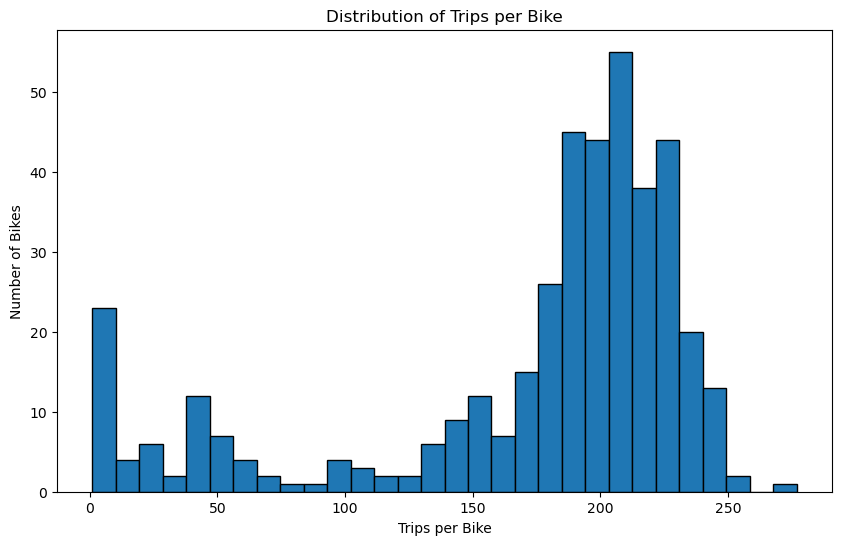

In [31]:

trips_per_bike = (
    sf_df.groupby('Bike #')['Trip ID']
    .nunique()  # distinct trips per bike
    .reset_index()
    .rename(columns={'Trip ID': 'trips_per_bike'})
)
bins = [0, 50, 150, 300, float('inf')]
labels = ['<50', '50–150', '150–300', '300+']

# Assign buckets
trips_per_bike['Usage_Bucket'] = pd.cut(
    trips_per_bike['trips_per_bike'],
    bins=bins,
    labels=labels,
    right=False,  
    include_lowest=True
)

# --- Step 3: Count bikes per bucket ---
bucket_counts = (
    trips_per_bike['Usage_Bucket']
    .value_counts()
    .reindex(labels, fill_value=0)
    .reset_index()
)
bucket_counts.columns = ['Usage_Bucket', 'Bike_Count']

# Add percentage
total_bikes = len(trips_per_bike)
bucket_counts['Percent'] = (bucket_counts['Bike_Count'] / total_bikes * 100).round(2)

print(bucket_counts)


plt.figure(figsize=(10,6))
plt.hist(trips_per_bike['trips_per_bike'], bins=30, edgecolor='black')
plt.title("Distribution of Trips per Bike")
plt.xlabel("Trips per Bike")
plt.ylabel("Number of Bikes")


## Station Flow and Imbalance Analysis

This section analyzes the flow of trips across stations by comparing outbound and inbound activity.

For each station, total outgoing trips, incoming trips, and net balance are calculated. This helps identify whether a station is a net supplier or receiver of bikes, highlighting imbalances in the system.

In [33]:
# Trips starting 
trips_out = sf_df.groupby('Start Station')['Trip ID'].count().reset_index()
trips_out.columns = ['Station', 'Trips_Out']

# Trips ending 
trips_in = sf_df.groupby('End Station')['Trip ID'].count().reset_index()
trips_in.columns = ['Station', 'Trips_In']

# Merge inbound and outbound on Station
station_flow = pd.merge(trips_out, trips_in, on='Station', how='outer').fillna(0)

# Total trips per station
station_flow['Total_Trips'] = station_flow['Trips_Out'] + station_flow['Trips_In']

# Net Balance (Outbound - Inbound)
station_flow['Net_Balance'] = station_flow['Trips_Out'] - station_flow['Trips_In']

# ✅ FIX: add this
station_flow['Relative_Imbalance_%'] = (
    station_flow['Net_Balance'] / station_flow['Total_Trips']
) * 100


# Sort for largest imbalance
largest_imbalance = station_flow.sort_values(by='Net_Balance', ascending=False).head(10)
largest_receivers = station_flow.sort_values(by='Net_Balance', ascending=True).head(10)

most_skewed = station_flow.sort_values(by='Relative_Imbalance_%', ascending=False).head(10)
most_negative_skew = station_flow.sort_values(by='Relative_Imbalance_%', ascending=True).head(10)


print("=== Stations with Largest Net Outflow ===")
print(largest_imbalance[['Station', 'Trips_Out', 'Trips_In', 'Net_Balance', 'Relative_Imbalance_%']])

print("\n=== Stations with Largest Net Inflow ===")
print(largest_receivers[['Station', 'Trips_Out', 'Trips_In', 'Net_Balance', 'Relative_Imbalance_%']])

=== Stations with Largest Net Outflow ===
                                          Station  Trips_Out  Trips_In  \
0                                   2nd at Folsom       2076      1200   
23                  Powell at Post (Union Square)       1642      1034   
4                                 Beale at Market       2102      1521   
18                                 Market at 10th       2503      2090   
29  Temporary Transbay Terminal (Howard at Beale)       3253      2922   
26                        San Francisco City Hall        616       351   
27                       South Van Ness at Market       1749      1489   
1                               2nd at South Park       2271      2017   
10                          Embarcadero at Bryant       1845      1616   
14                            Golden Gate at Polk       1005       788   

    Net_Balance  Relative_Imbalance_%  
0           876             26.739927  
23          608             22.720478  
4           581        

### Key Insights

- Certain stations act as major departure hubs, while others serve as key arrival points  
- Strong directional flow suggests commute-driven movement across the network  
- High-traffic stations show the largest imbalances, creating operational pressure  
- Some smaller stations also have high relative imbalance, indicating hidden inefficiencies  

**Insight:** Bike demand is directional, requiring rebalancing between origin and destination hubs.

In [35]:
# Top 5 most used routes
routes = (
    sf_df.groupby(['Start Station', 'End Station'])['Trip ID']
    .count()
    .reset_index()
    .rename(columns={'Trip ID': 'Trips'})
    .sort_values(by='Trips', ascending=False)
    .head(5)
)

print("=== Top 5 Most Used Routes ===")
print(routes)


=== Top 5 Most Used Routes ===
                               Start Station  \
492     Harry Bridges Plaza (Ferry Building)   
951                          Townsend at 7th   
798  San Francisco Caltrain 2 (330 Townsend)   
79                           2nd at Townsend   
411                   Embarcadero at Sansome   

                                  End Station  Trips  
492                    Embarcadero at Sansome    923  
951  San Francisco Caltrain (Townsend at 4th)    790  
798                           Townsend at 7th    736  
79       Harry Bridges Plaza (Ferry Building)    597  
411                         Steuart at Market    577  


## Top and Bottom Stations by Usage

In [37]:
top_5 = station_flow.sort_values(by='Total_Trips', ascending=False).head(5)
print(top_5)

bottom_5 = station_flow.sort_values(by='Total_Trips', ascending=True).head(5)
print(bottom_5)

                                     Station  Trips_Out  Trips_In  \
24  San Francisco Caltrain (Townsend at 4th)       6495      8385   
15      Harry Bridges Plaza (Ferry Building)       4108      3926   
12                    Embarcadero at Sansome       3458      4116   
25   San Francisco Caltrain 2 (330 Townsend)       3664      3741   
20                         Market at Sansome       3320      3773   

    Total_Trips  Net_Balance  Relative_Imbalance_%  
24        14880        -1890            -12.701613  
15         8034          182              2.265372  
12         7574         -658             -8.687616  
25         7405          -77             -1.039838  
20         7093         -453             -6.386578  
                      Station  Trips_Out  Trips_In  Total_Trips  Net_Balance  \
17                MLK Library         21        21           42            0   
26    San Francisco City Hall        616       351          967          265   
31       Washington at Kear

### Key Insights

- Top stations like Caltrain and Ferry Building handle the highest traffic, acting as major demand hubs  
- These stations also show strong inflow, indicating they are key destinations  
- Bottom stations like MLK Library have very low usage, indicating underutilization  
- Some smaller stations show high imbalance %, suggesting localized inefficiencies  

**Insight:** Demand is concentrated at a few major hubs, while several stations remain underutilized, highlighting opportunities for better resource distribution.

### Percentage from top 5

In [39]:
total = station_flow['Total_Trips'].sum()
top5_sum = top_5['Total_Trips'].sum()

print((top5_sum / total) * 100)

31.726307178018814


# --- Trip Duration Bucket Analysis ---

In [40]:


# --- Trip Duration Bucket Analysis ---
# Assumes sf_df has 'Trip Duration Min' column

# Define buckets (in minutes)
bins = [0, 10, 20, 30, 60, 120, 180, float('inf')]
labels = ['0–10', '10–20', '20–30', '30–60', '60–120', '120–180', '180+']

# Assign each trip to a duration bucket
sf_df['Duration_Bucket'] = pd.cut(
    sf_df['Trip Duration Min'],
    bins=bins,
    labels=labels,
    right=False,          # include left edge, exclude right
    include_lowest=True
)

# Count trips per bucket
bucket_counts = sf_df['Duration_Bucket'].value_counts().reindex(labels, fill_value=0).reset_index()
bucket_counts.columns = ['Duration_Bucket', 'Trips']

# Total trips
total_trips = len(sf_df)

# Add percentage
bucket_counts['Percent'] = (bucket_counts['Trips'] / total_trips * 100).round(2)

print("=== Trip Duration Distribution ===")
print(bucket_counts)

# Extra metrics: Long trips
over_120 = (sf_df['Trip Duration Min'] >= 120).sum()
over_180 = (sf_df['Trip Duration Min'] >= 180).sum()

print(f"\nTrips > 120 min: {over_120} ({(over_120/total_trips*100):.2f}%)")
print(f"Trips > 180 min: {over_180} ({(over_180/total_trips*100):.2f}%)")


=== Trip Duration Distribution ===
  Duration_Bucket  Trips  Percent
0            0–10  41912    59.12
1           10–20  22153    31.25
2           20–30   3080     4.34
3           30–60   1509     2.13
4          60–120    808     1.14
5         120–180    491     0.69
6            180+    944     1.33

Trips > 120 min: 1435 (2.02%)
Trips > 180 min: 944 (1.33%)


In [41]:
median_duration = sf_df['Trip Duration Min'].median()
print("Median Trip Duration (minutes):", median_duration)


Median Trip Duration (minutes): 8.83


In [42]:
# Filter only valid numeric 5-digit zips
known_zips = sf_df[sf_df['zip_known']]['Zip Code Clean'].nunique()

print("Number of unique known zip codes:", known_zips)


Number of unique known zip codes: 2020


In [43]:
# Total duration in minutes
total_minutes = sf_df['Trip Duration Min'].sum()

# Convert to hours
total_hours = round(total_minutes / 60, 2)

print("Total Trip Duration (hours):", total_hours)


Total Trip Duration (hours): 20466.38
